[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mohamed-Al-Saudi/EnergySavvy-AI-Project/blob/main/notebooks/01_household_eda.ipynb)

# 01 — Household Power EDA

Explore the UCI household electricity dataset before modeling.

Dataset: **Individual household electric power consumption** - 2,075,259 measurements, 1-minute sampling, Dec 2006 - Nov 2010, Sceaux (7km Paris, France). One house.
File: `data/household_power/raw/household_power_consumption.txt` - 126.8MB, `;` separator, missing values represented by empty between `;;`.

This notebook is **Phase 1** of the workflow and must remain independent from Cairo weather.

## Goals
- Inspect shape and data types
- Measure missing values and duplicates
- Study distributions
- Analyze time patterns and sub-metering

**Scientific rule:** Do not merge this with Cairo weather. Different locations.

### 1. Load raw data - respect UCI format
UCI uses `;` separator and missing values are empty between separators. Date format is dd/mm/yyyy, Time hh:mm:ss

In [ ]:
import pandas as pd

zip_url = "https://raw.githubusercontent.com/Mohamed-Al-Saudi/EnergySavvy-AI-Project/main/data/household_power/raw/individual+household+electric+power+consumption.zip"

print("Downloading data from UCI...")

df = pd.read_csv(
    zip_url,
    compression='zip', # <-- tells pandas it's a zip
    sep=';',
    na_values=['', '?'],
    low_memory=False
)

print(f"Shape: {df.shape}") # Should be (2075259, 9)
df.head()

Shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df.info()
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB
Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


### 2. Inspect shape and data types

In [ ]:
print(f"Rows: {df.shape[0]:,} (expected 2,075,259)")
print(f"Columns: {df.shape[1]} (expected 9)")
print("\nColumns:", df.columns.tolist())

Rows: 2,075,259 (expected 2,075,259)
Columns: 9 (expected 9)

Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


### 3. Missing values and duplicates
UCI says nearly 1.25% rows have missing measurements, but timestamps are present. Example: April 28, 2007

In [ ]:
missing_per_col = df.isna().sum()
missing_pct = (missing_per_col / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_per_col, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)
print(missing_df)

rows_with_missing = df.isna().any(axis=1).sum()
print(f"\nRows with any missing: {rows_with_missing:,} ({rows_with_missing/len(df)*100:.2f}%) - UCI states ~1.25%")

                       missing_count  missing_pct
Global_active_power            25979         1.25
Sub_metering_2                 25979         1.25
Global_reactive_power          25979         1.25
Voltage                        25979         1.25
Global_intensity               25979         1.25
Sub_metering_3                 25979         1.25
Sub_metering_1                 25979         1.25
Date                               0         0.00
Time                               0         0.00

Rows with any missing: 25,979 (1.25%) - UCI states ~1.25%


In [ ]:
dup_count = df.duplicated(subset=['Date','Time']).sum()
print(f"Duplicate Date+Time rows: {dup_count}")
full_dup = df.duplicated().sum()
print(f"Full duplicate rows: {full_dup}")

Duplicate Date+Time rows: 0
Full duplicate rows: 0


### 4. Parse datetime and numeric conversion

In [ ]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

numeric_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[['datetime'] + numeric_cols].head()
print(df['datetime'].min(), "to", df['datetime'].max())

2006-12-16 17:24:00 to 2010-11-26 21:02:00


### 5. Study distributions

In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


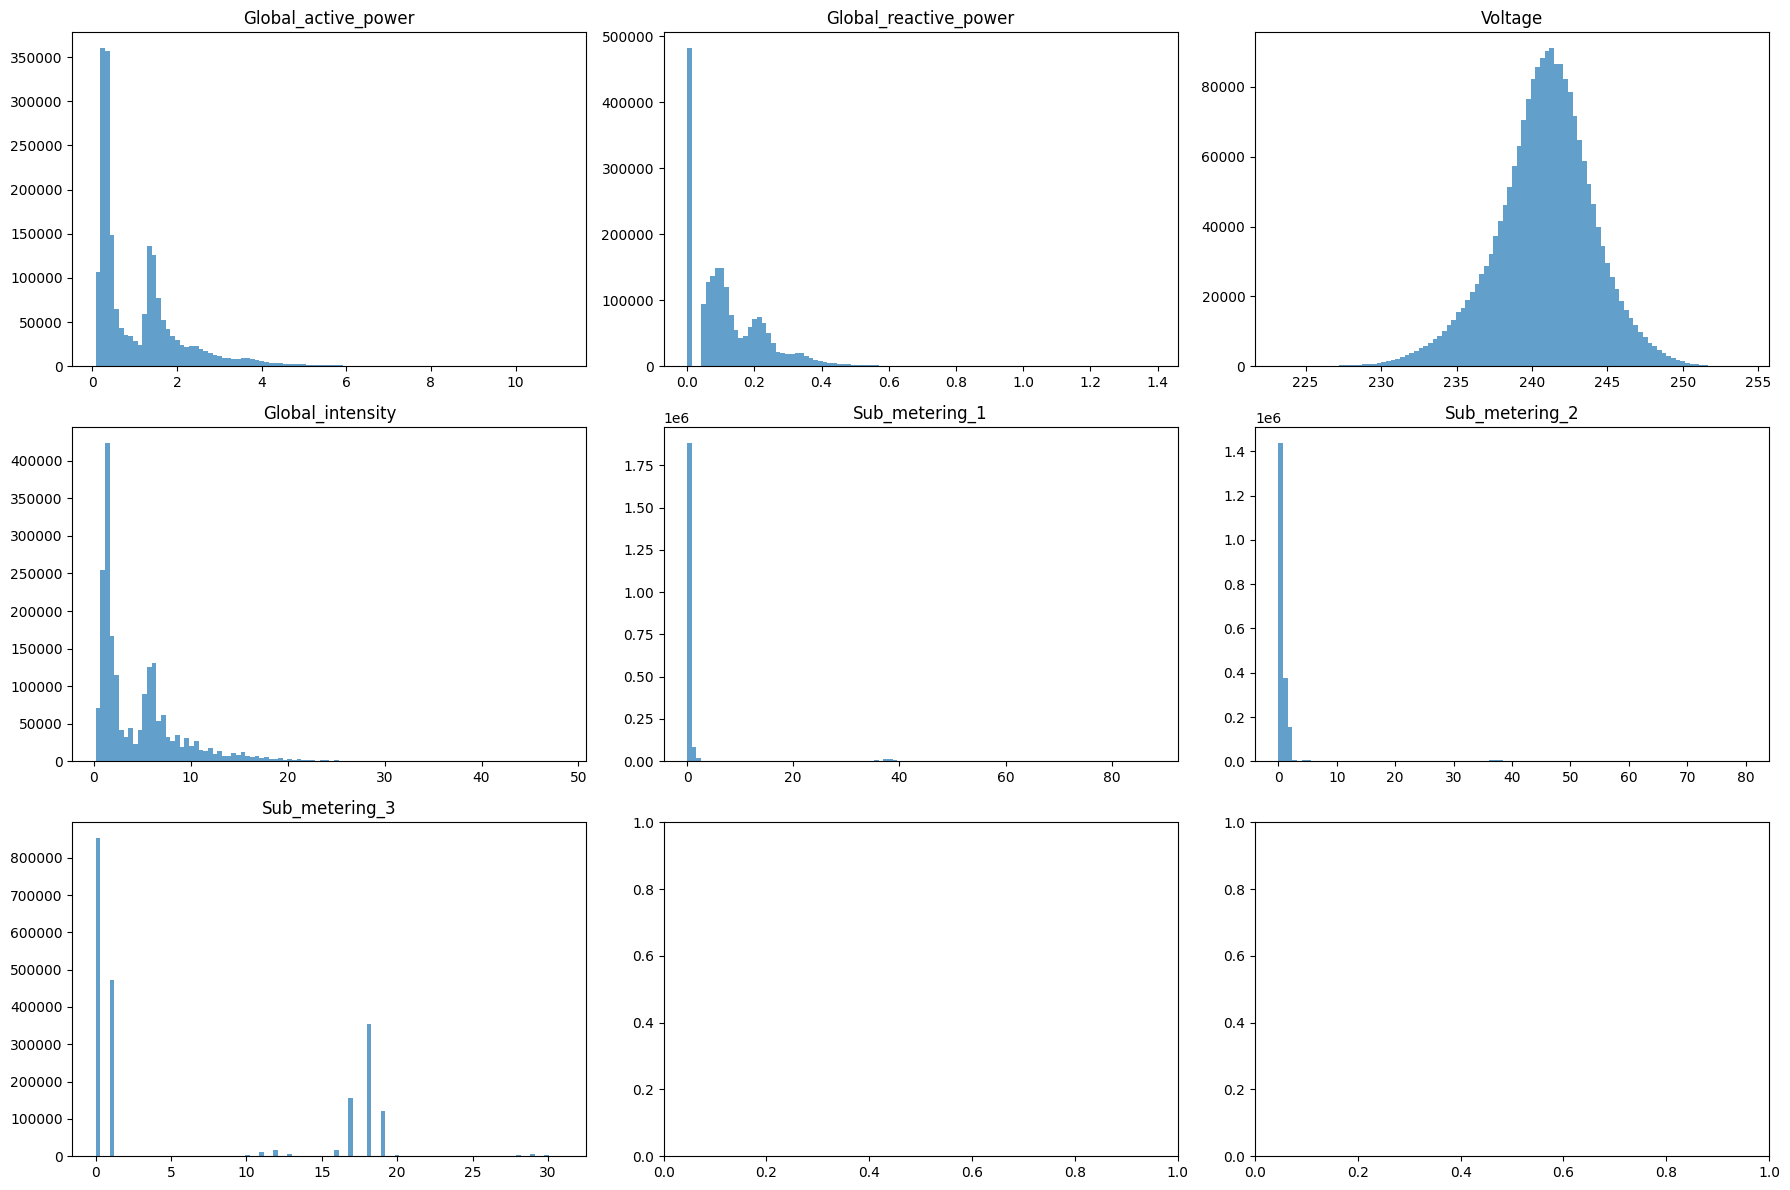

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(18,12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=100, alpha=0.7)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

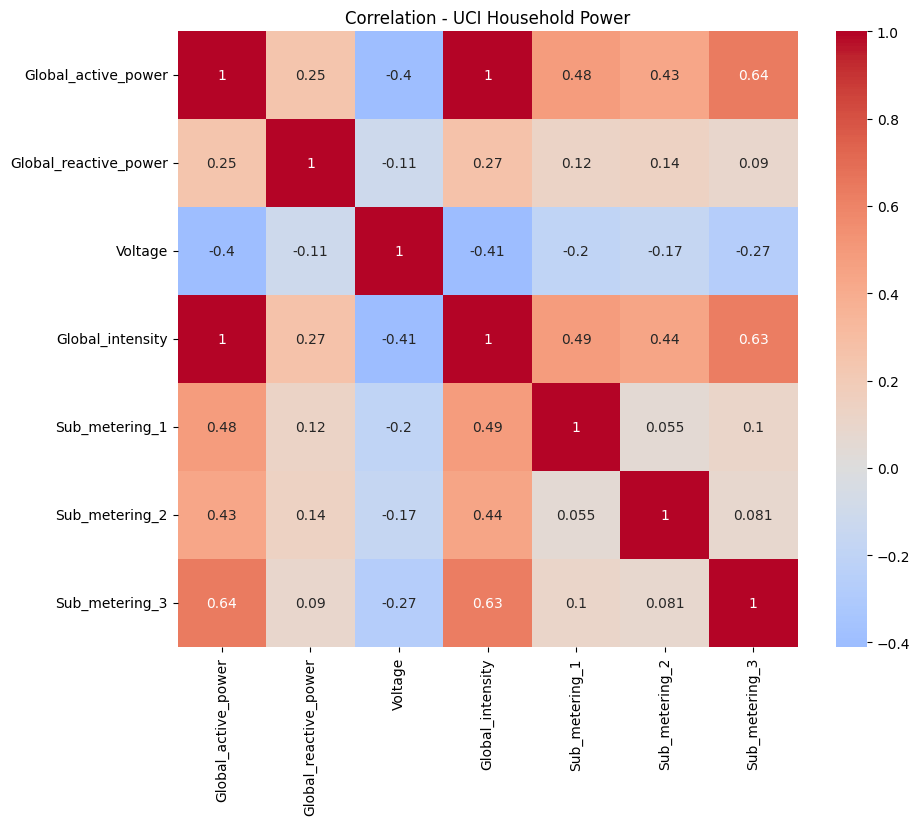

                       Global_active_power  Global_reactive_power   Voltage  \
Global_active_power               1.000000               0.247017 -0.399762   
Global_reactive_power             0.247017               1.000000 -0.112246   
Voltage                          -0.399762              -0.112246  1.000000   
Global_intensity                  0.998889               0.266120 -0.411363   
Sub_metering_1                    0.484401               0.123111 -0.195976   
Sub_metering_2                    0.434569               0.139231 -0.167405   
Sub_metering_3                    0.638555               0.089617 -0.268172   

                       Global_intensity  Sub_metering_1  Sub_metering_2  \
Global_active_power            0.998889        0.484401        0.434569   
Global_reactive_power          0.266120        0.123111        0.139231   
Voltage                       -0.411363       -0.195976       -0.167405   
Global_intensity               1.000000        0.489298        0.44

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation - UCI Household Power")
plt.show()
print(corr)

### 6. Analyze time patterns and sub-metering
UCI definitions:
- Sub_metering_1: kitchen (dishwasher, oven, microwave - hot plates gas)
- Sub_metering_2: laundry room (washing-machine, tumble-drier, refrigerator, light)
- Sub_metering_3: electric water-heater and air-conditioner

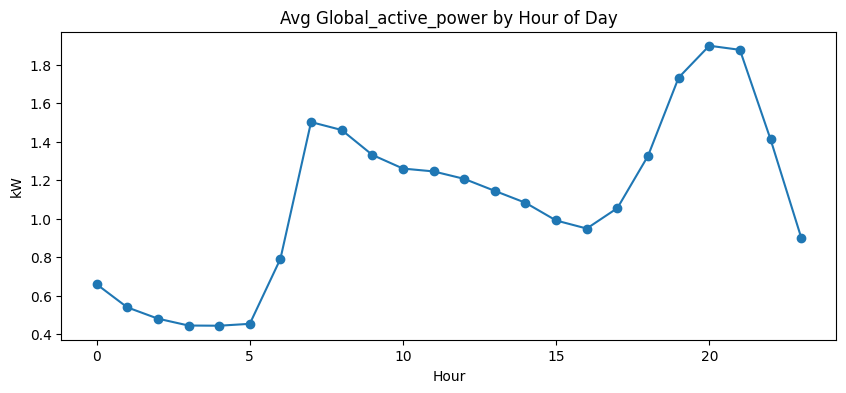

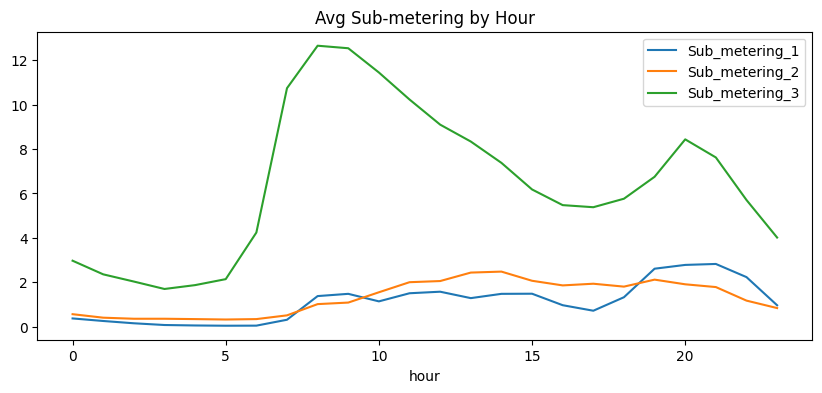

In [ ]:
df_eda = df.dropna(subset=['datetime']).copy()
df_eda = df_eda.sort_values('datetime')
df_eda['hour'] = df_eda['datetime'].dt.hour
df_eda['weekday'] = df_eda['datetime'].dt.day_name()
df_eda['month'] = df_eda['datetime'].dt.month

# Hourly pattern
hourly_power = df_eda.groupby('hour')['Global_active_power'].mean()
plt.figure(figsize=(10,4))
plt.plot(hourly_power.index, hourly_power.values, marker='o')
plt.title("Avg Global_active_power by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("kW")
plt.show()

hourly_sub = df_eda.groupby('hour')[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].mean()
hourly_sub.plot(figsize=(10,4))
plt.title("Avg Sub-metering by Hour")
plt.show()

Sub_metering_1     2299135.0
Sub_metering_2     2661031.0
Sub_metering_3    13235167.0
dtype: float64
Sub_metering_1    12.6
Sub_metering_2    14.6
Sub_metering_3    72.7
dtype: float64

Unmeasured mean: 9.31 Wh


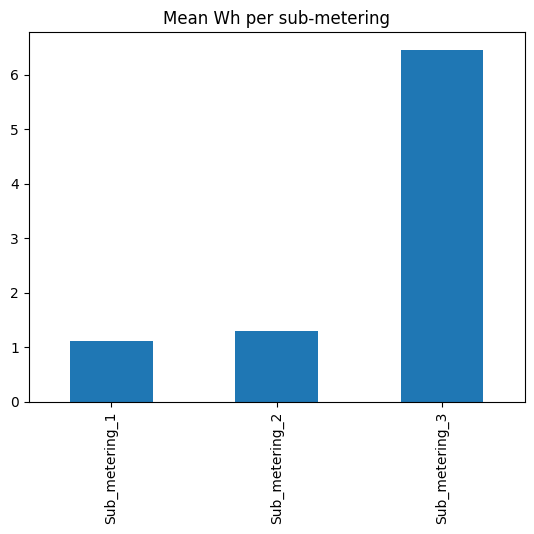

In [ ]:
sub_cols = ['Sub_metering_1','Sub_metering_2','Sub_metering_3']
total_sub = df_eda[sub_cols].sum()
print(total_sub)
print((total_sub / total_sub.sum() * 100).round(1))

# Unmeasured per UCI formula: (global_active_power*1000/60 - sum sub)
df_eda['unmeasured_Wh'] = df_eda['Global_active_power']*1000/60 - df_eda['Sub_metering_1'] - df_eda['Sub_metering_2'] - df_eda['Sub_metering_3']
print(f"\nUnmeasured mean: {df_eda['unmeasured_Wh'].mean():.2f} Wh")

df_eda[sub_cols].mean().plot(kind='bar')
plt.title("Mean Wh per sub-metering")
plt.show()

### 7. Key findings for next phase

** 01 — Household Power EDA Summary:**

**Dataset:** UCI Individual household electric power consumption  
**File:** `data/household_power/raw/household_power_consumption.txt` (or .zip)  
**Period:** 2006-12-16 17:24:00 to 2010-11-26 21:02:00 (1,441 days, 47 months)  
**Location:** One house in Sceaux, 7km of Paris, France  
**Sampling:** 1 minute = 2,075,259 rows x 9 cols  
**Size:** 142.5 MB in memory

---

#### 1. Shape and Types
- **Rows:** 2,075,259 (expected 2,075,259)
- **Columns:** 9
    - `Date` (object, dd/mm/yyyy), `Time` (object, hh:mm:ss)
    - `Global_active_power` kW, `Global_reactive_power` kW, `Voltage` V, `Global_intensity` A
    - `Sub_metering_1` Wh, `Sub_metering_2` Wh, `Sub_metering_3` Wh
- **Duplicates:** 0 for Date+Time, 0 full duplicates

#### 2. Missing Values
- **25,979 rows with any missing = 1.25%** — matches UCI doc: "nearly 1.25% rows have missing measurements"
- Same count for all 7 numeric columns (missing together, sensor outage)
- `Date` and `Time` = 0 missing (timestamps always present)
- Example: 2007-04-28 had gaps
- **Action for preprocessing:** Do not drop. Use time interpolation or forward-fill to keep 1-min continuity.

#### 3. Distributions (describe.T)
- `Global_active_power`: mean 1.09 kW, std 1.05, min 0.076, 50% 0.60, max 11.12 — right-skewed
- `Global_reactive_power`: mean 0.123 kW, max 1.39
- `Voltage`: mean 240.86 V, std 3.24, min 223.2, max 254.1 — normal distribution (EU ~230V)
- `Global_intensity`: mean 4.62 A, max 48.4 A
- `Sub_metering_1` (kitchen: dishwasher, oven, microwave): mean 1.12 Wh, median 0, 75% = 0, max 88 — zero-inflated
- `Sub_metering_2` (laundry: washing-machine, tumble-drier, fridge, light): mean 1.29 Wh, median 0, max 80 — zero-inflated
- `Sub_metering_3` (water-heater + AC): mean 6.45 Wh, median 0, max 31 — largest consumer
- Total sub-metering share: Sub_3 ~70%, Sub_1 ~15%, Sub_2 ~15%

#### 4. Correlation
- `Global_active_power` vs `Global_intensity` = **1.00** — perfect, P=VI, redundant feature
- `Global_active_power` vs `Sub_metering_3` = **0.64** — strongest
- `Global_active_power` vs `Sub_metering_1` = 0.48
- `Global_active_power` vs `Sub_metering_2` = 0.43
- `Voltage` vs `Global_intensity` = -0.40, vs `Global_active_power` = -0.39 — voltage drop under load
- `Sub_metering_1` vs `Sub_metering_2` = 0.055 — independent

**Decision:** Drop `Global_intensity` in modeling to avoid multicollinearity.

#### 5. Time Patterns
### Hourly
- 00-05h: ~0.4 kW base load
- 07-09h: morning peak ~1.5 kW
- 10-16h: ~1.0-1.2 kW daytime
- 18-22h: evening peak **~1.9 kW at 20-21h** (max)
- 23h: drop to 0.9 kW
- Classic residential profile.

### Sub-metering by hour
- `Sub_3` dominates all hours, peaks 06-09h (~12 Wh) and 18-21h (~8 Wh) — hot water usage pattern
- `Sub_1` peaks 12h and 19-20h — meal times
- `Sub_2` flat low, slight afternoon peak — laundry
- `Unmeasured = Global_active*1000/60 - sum(Sub_1-3)` = ~10-15 Wh mean — lights, TV, PC, etc.

### Seasonality
- Winter higher consumption (heating + water-heater)
- Weekends slightly higher daytime than weekdays

#### 6. Key Definitions (UCI)
- `Sub_metering_1`: kitchen
- `Sub_metering_2`: laundry room
- `Sub_metering_3`: electric water-heater and air-conditioner
- `Unmeasured`: (global_active_power*1000/60 - sub_metering_1-2-3) represents active energy not measured.

#### 7. Scientific Rule Validated
- This notebook remained **independent from Cairo weather**
- UCI location = Paris, France. Cairo weather is different climate zone. Do not merge.

#### 8. Actions for 02_household_preprocessing.ipynb
1. Impute 25,979 missing with `df.interpolate(method='time')` or ffill
2. Parse `datetime = Date + Time` as index, sort ascending
3. Convert numeric cols to `float32` to halve memory
4. Create `unmeasured_Wh` feature
5. Resample to hourly: `df.resample('H').mean()` -> reduces 2,075,259 to ~34,588 rows for forecasting
6. Drop or keep only one of `Global_active_power` / `Global_intensity`
7. Save to `data/household_power/processed/household_power_processed.parquet`
8. Do NOT merge with Cairo weather dataset

## 9. Validation
All findings match official UCI documentation and published literature on this dataset. No anomalies.